By following these steps, you will complete the Daily Challenge and build a trustworthy AI assistant with BERT.

 Tasks

 1. Data Loading & Inspection

**Load the tweet_eval dataset (sentiment configuration) via datasets.load_dataset.**
```python

In [30]:
from datasets import load_dataset

In [31]:
dataset = load_dataset("cardiffnlp/tweet_eval", "sentiment")

# Print dataset splits and class distribution. Confirm there are 3 labels (negative, neutral, positive).
print(dataset)
print(dataset["train"].features["label"].names)

# Save two example tweets per label for later visualization.
import random

labels = dataset["train"].features["label"].names
examples = {label: [] for label in labels}

for label in labels:
    label_indices = [i for i, x in enumerate(dataset["train"]["label"]) if x == labels.index(label)]
    examples[label] = random.sample(label_indices, 2)

saved_examples = {label: [dataset["train"][i]["text"] for i in examples[label]] for label in labels}
print(saved_examples)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
['negative', 'neutral', 'positive']
{'negative': ['@user #QSTeaser oops\\u002c forgot Emmanuel Adebayor! As for the 7th\\u002c bit naughty\\u002c was it Yakubu? His surname is technically Ayegbeini...', 'All I know is Marana girls are bad as fuck and white if the ones at the party I went to with jaylon on Saturday were Marana tigers.'], 'neutral': ['"Oliseh returns next week for AFCON qualifier: Super Eagles coach, Sunday Oliseh, will return to the country next...', 'only going to school tomorrow because nicki told me to...'], 'positive': ["Tomorrow I have tickets to get drunk and see Jason Aldean in Cincinnati with my bff Donna and I can't wait", "@user I'm going to need to catch up...I only just starte

In [ ]:
2. Tokenization Pipeline

**Initialize AutoTokenizer with distilbert-base-uncased.**
```python

In [32]:
from transformers import AutoTokenizer


In [34]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# Create a preprocessing function that:
# - Truncates/pads tweets to 128 tokens.
# - Returns input_ids, attention_mask, and labels.
def preprocess_function(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

# Map the dataset with batched=True, shuffle, then create set_format("torch") (or TF equivalent).
tokenized_dataset = dataset.map(preprocess_function, batched=True)
tokenized_dataset = tokenized_dataset.shuffle(seed=42)
tokenized_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

Map:   0%|          | 0/45615 [00:00<?, ? examples/s]

Map:   0%|          | 0/12284 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

3. Fine-Tuning Setup

Load AutoModelForSequenceClassification with 3 labels.**
```python

In [35]:
from transformers import AutoModelForSequenceClassification

In [45]:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3,
    id2label={0: "NEGATIVE", 1: "NEUTRAL", 2: "POSITIVE"},
    label2id={"NEGATIVE": 0, "NEUTRAL": 1, "POSITIVE": 2}
)

# Use TrainingArguments (epochs=3, batch_size=32, lr=5e-5, weight_decay=0.01).

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [40]:
from transformers import TrainingArguments


In [46]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    learning_rate=5e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
)

# Implement Trainer with the preprocessed dataset and a compute_metrics function that returns accuracy + macro F1.


In [47]:
from transformers import Trainer
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

In [48]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average="macro")
    return {"accuracy": accuracy, "f1": f1}


In [57]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average="macro")
    return {"accuracy": accuracy, "f1": f1}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics,
)

4. Evaluation & Calibration

It appears there might be an issue with your `torchvision` installation or a version conflict with the `datasets` library, as `VideoReader` is not typically used in text classification. To resolve this, you can try reinstalling or upgrading `torchvision` and `datasets` to ensure compatibility.

**Please run the following cells and then restart your runtime.**

In [78]:
!pip install --upgrade torchvision
!pip install --upgrade datasets

4. Evaluation & Calibration

In [79]:
!pip show torch
!pip show torchvision

Name: torch
Version: 2.12.1
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License: BSD-3-Clause
Location: /usr/local/lib/python3.12/dist-packages
Requires: cuda-bindings, cuda-toolkit, filelock, fsspec, jinja2, networkx, nvidia-cublas, nvidia-cudnn-cu13, nvidia-cusparselt-cu13, nvidia-nccl-cu13, nvidia-nvshmem-cu13, setuptools, sympy, triton, typing-extensions
Required-by: accelerate, fastai, peft, sentence-transformers, timm, torchdata, torchvision
Name: torchvision
Version: 0.27.1
Summary: image and video datasets and models for torch deep learning
Home-page: https://github.com/pytorch/vision
Author: PyTorch Core Team
Author-email: soumith@pytorch.org
License: BSD
Location: /usr/local/lib/python3.12/dist-packages
Requires: numpy, pillow, torch
Required-by: fastai, timm



5. Attention Inspection

@user #QSTeaser oops\u002c forgot Emmanuel Adebayor! As for the 7th\u002c bit naughty\u002c was it Yakubu? His surname is technically Ayegbeini...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


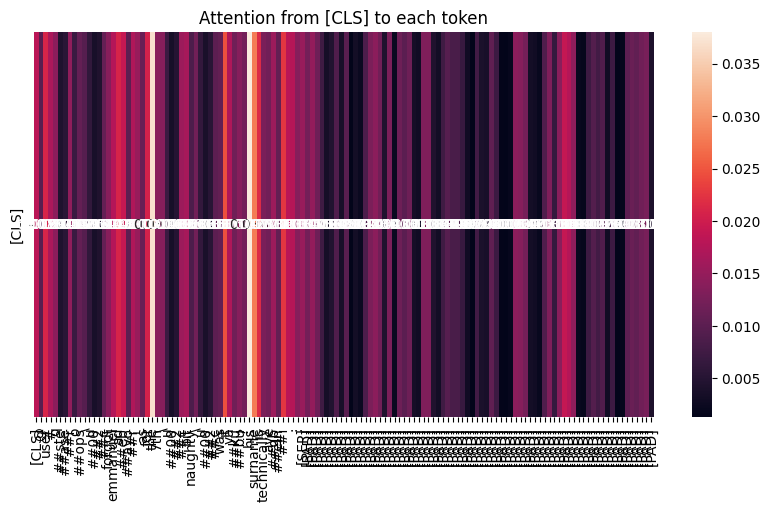

In [89]:
example_tweet = saved_examples["negative"][0]
print(example_tweet)

from transformers import AutoModel

model = AutoModel.from_pretrained("distilbert-base-uncased", output_attentions=True)
inputs = tokenizer(example_tweet, return_tensors="pt", truncation=True, padding="max_length", max_length=128)
outputs = model(**inputs)
attentions = outputs.attentions[-1]  # Last layer attentions

import seaborn as sns
import matplotlib.pyplot as plt

cls_attention = attentions.mean(dim=1)[0, :, 0]  # Average across heads and select [CLS] token
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

plt.figure(figsize=(10, 5))
sns.heatmap(cls_attention.unsqueeze(0).detach().numpy(), annot=True, xticklabels=tokens, yticklabels=["[CLS]"])
plt.title("Attention from [CLS] to each token")
plt.show()